In [1]:
import numpy as np
import matplotlib.pyplot as plt


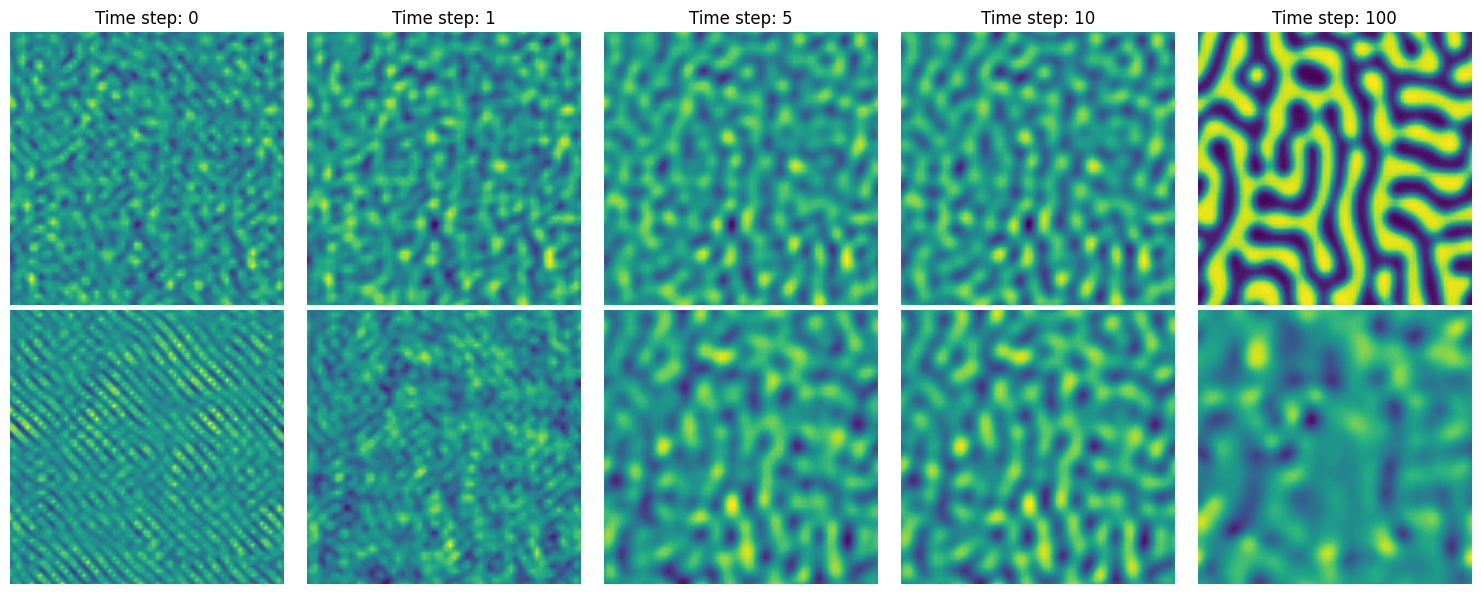

In [2]:
save_dir = "./data"
solutions = np.load(f"{save_dir}/train_valid/solutions_grid.npy")[:, :, :, :-1, :-1]
mesh = np.load(f"{save_dir}/train_valid/mesh_grid_coords.npy")
mesh = np.transpose(mesh, (2, 0, 1))[:, :-1, :-1]
meshx = mesh[0, :, :]
meshy = mesh[1, :, :]
tics = [0, 1, 5, 10,100]

fig, axes = plt.subplots(2, len(tics), figsize=(15, 6))
for i, tic in enumerate(tics):
    ax = axes[0, i]
    im = ax.contourf(meshx, meshy, solutions[0, tic, 0, ...],
                     levels=50, cmap='viridis')
    ax.set_title(f'Time step: {tic}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    # fig.colorbar(im, ax=ax)
    ax.set_aspect('equal')
    ax.set_axis_off()

    ax = axes[1, i]
    im = ax.contourf(meshx, meshy, solutions[0, tic, 1, ...],
                     levels=50, cmap='viridis')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    # fig.colorbar(im, ax=ax)
    ax.set_aspect('equal')
    ax.set_axis_off()
fig.tight_layout()

In [3]:
solutions[0, 1, 1, ...].min(), solutions[0, 1, 1, ...].max()

(np.float64(-0.12698357202596586), np.float64(0.14636415477933343))

In [4]:
solutions.shape

(20, 101, 2, 64, 64)

In [5]:
from configs.train_debug import Configs
configs = Configs()

def prepare_data(data_dir):

    mesh = np.load(f"{data_dir}/mesh_grid_coords.npy")
    mesh = np.transpose(mesh, (2, 0, 1))[:, :-1, :-1]
    meshx = mesh[0, :, :]
    meshy = mesh[1, :, :]
    times = np.load(f"{data_dir}/times.npy")
    dt = times[1] - times[0]
    num_times = times.shape[0]
    solutions = np.load(f"{data_dir}/solutions_grid.npy", allow_pickle=True)[:, :, :, :-1, :-1]
    num_ics = solutions.shape[0]
    Xs = np.zeros(
        ((num_times-1)*num_ics, 4, mesh.shape[1], mesh.shape[2])
    ) 
    Ys = np.zeros(
        ((num_times-1)*num_ics, 2, mesh.shape[1], mesh.shape[2])
    )

    for i in range(num_ics):
        Xs[i*(num_times-1):(i+1)*(num_times-1), 0, :, :] = solutions[i, :-1, 0, :, :]  # phi
        Xs[i*(num_times-1):(i+1)*(num_times-1), 1, :, :] = solutions[i, :-1, 1, :, :]  # c
        # mesh_x_repeated = np.repeat(mesh[:, :, 0][np.newaxis, :, :], num_times-1, axis=0)
        # Xs[i*(num_times-1):(i+1)*(num_times-1), 2, :, :] = mesh_x_repeated / configs.Lc  # x
        # mesh_y_repeated = np.repeat(mesh[:, :, 1][np.newaxis, :, :], num_times-1, axis=0)
        # Xs[i*(num_times-1):(i+1)*(num_times-1), 3, :, :] = mesh_y_repeated / configs.Lc # y

        Ys[i*(num_times-1):(i+1)*(num_times-1), 0, :, :] = solutions[i, 1:, 0, :, :]  # phi at next time step
        Ys[i*(num_times-1):(i+1)*(num_times-1), 1, :, :] = solutions[i, 1:, 1, :, :]  # c
    meshes_repeated = np.repeat(mesh[np.newaxis, :, :, :], Xs.shape[0], axis=0)
    Xs[:, 2, :, :] = meshes_repeated[:, 0, :, :] / configs.Lc  # x
    Xs[:, 3, :, :] = meshes_repeated[:, 1, :, :] / configs.Lc # y
    return Xs, Ys
Xs, Ys = prepare_data(f"{save_dir}/train_valid")
Xs_init_steps, Ys_init_steps = prepare_data(f"{save_dir}/train_init_steps")
Xs = np.concatenate([Xs, Xs_init_steps], axis=0)
Ys = np.concatenate([Ys, Ys_init_steps], axis=0)
Xs.shape, Ys.shape

((2200, 4, 64, 64), (2200, 2, 64, 64))

-0.2428653483780145 0.2645539599373362 -0.1906981292129758 0.1890004736357993 9.093493725888246e-06 0.10390620002546858
-0.2503941984941863 0.23880768129806246 -0.27365097406346883 0.2595117114584195 4.6629370521657915e-07 0.026384167574876882
-0.35783713550559143 0.34148416841823737 -0.3890920913124306 0.3723867929717444 1.0971869340101886e-06 0.036010089194876915


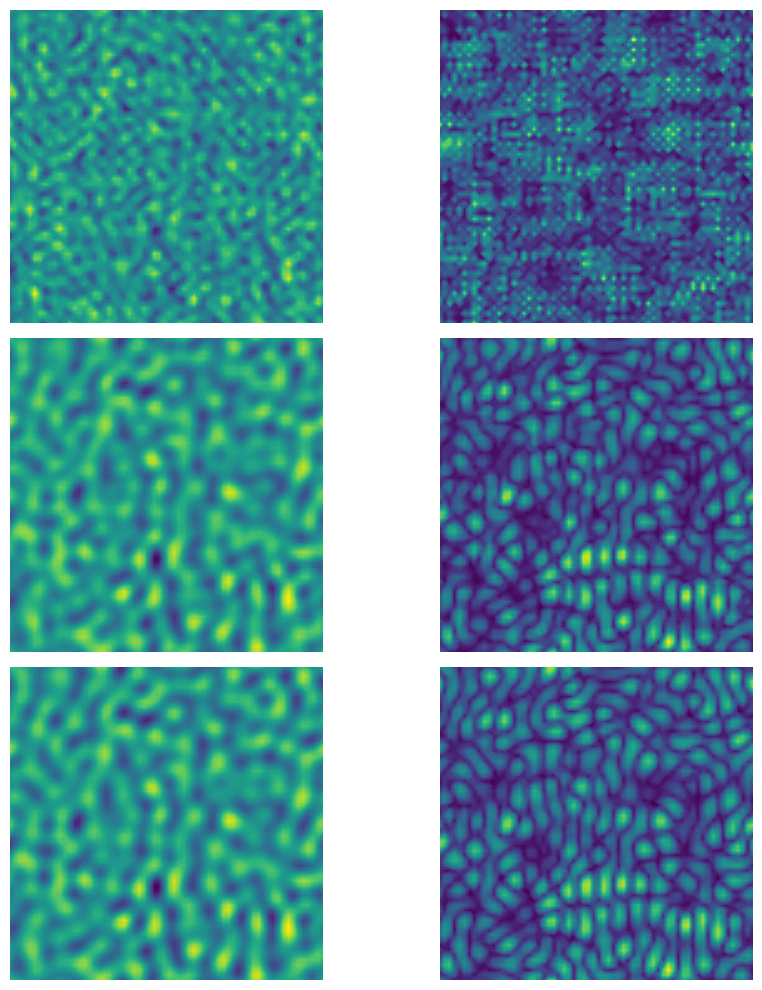

In [6]:
import matplotlib.pyplot as plt
ts = [0, 5, 9]
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
for idx, t in enumerate(ts):
    t += 0
    x = Xs[t, 0, :, :]
    y = Ys[t, 0, :, :]
    meshx = Xs[t, 2, :, :] * configs.Lc
    meshy = Xs[t, 3, :, :] * configs.Lc
    ax = axes[idx, 0]
    # im = ax.pcolormesh(meshx, meshy, x, cmap="coolwarm")
    ax.contourf(meshx, meshy, x, levels=50, cmap='viridis')
    ax.set_aspect('equal')
    ax.set_axis_off()

    ax = axes[idx, 1]
    diff = np.abs(y - x)
    # im = ax.pcolormesh(meshx, meshy, diff, cmap="coolwarm")
    ax.contourf(meshx, meshy, diff, levels=50, cmap='viridis')
    ax.set_aspect('equal')
    ax.set_axis_off()
    print(x.min(), x.max(), y.min(), y.max(), diff.min(), diff.max())
fig.tight_layout()


[0.08617799 0.01177534 0.00476693 0.00336844 0.00322213 0.00340456
 0.00369472 0.0040265  0.0043748  0.00472338 0.00505601 0.00535437
 0.00559634 0.00575782 0.00581292 0.00574262 0.00553674 0.00521963
 0.00483775 0.00447524]


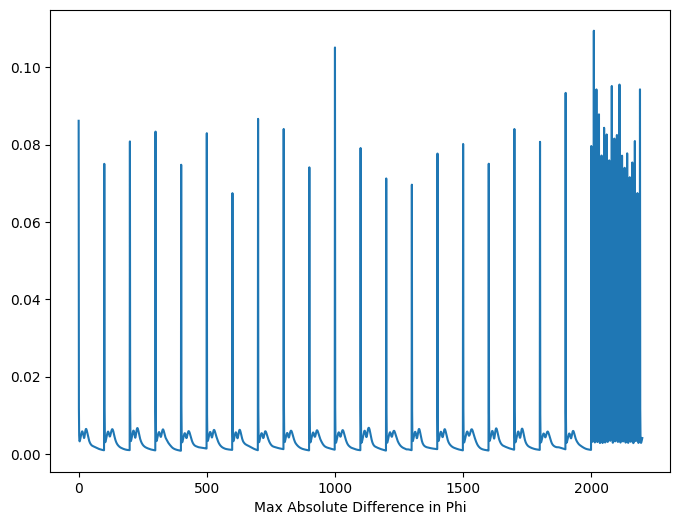

In [7]:
diffs = Xs[:, 1, ...] - Ys[:, 1, ...]
diffs = np.abs(diffs)

# diffs[:, 0].max(), diffs[:, 1].max(), diffs[:, 0].min(), diffs[:, 1].min()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.plot(diffs.mean(axis=(-1,-2)))
ax.set_xlabel('Max Absolute Difference in Phi')
print(np.mean(diffs, axis=(-1,-2))[:20])

In [8]:
times = np.load(f"{save_dir}/train_valid/times.npy")
dt = times[1] - times[0]
dt

np.float64(5e-05)

In [9]:
np.savez(
    "./data/train_valid/dataset_2d_complete.npz",
    meshes=mesh/configs.Lc,
    times=times/configs.Tc,
    Xs=Xs,
    Ys=Ys,
)

In [10]:
Xs.shape, Ys.shape

((2200, 4, 64, 64), (2200, 2, 64, 64))

In [11]:
import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", False)

class Spectral2d:
    """
    Spectral Method for 2D derivatives with Periodic BC.
    
    This method is architecture-agnostic and works for any grid-based model 
    (CNN, FNO, or Hybrid) as long as the physical problem has Periodic BCs.
    It computes derivatives in the frequency domain to minimize numerical dispersion,
    which is especially beneficial for high-frequency initial conditions.
    """
    @staticmethod
    def nabla(
        u: jnp.ndarray,
        dx: float,
        dy: float
    ) -> jnp.ndarray:
        H, W = u.shape
        u_hat = jnp.fft.fft2(u)
        
        kx = 2 * jnp.pi * jnp.fft.fftfreq(W, d=dx)
        ky = 2 * jnp.pi * jnp.fft.fftfreq(H, d=dy)
            
        kx = kx[None, :]
        ky = ky[:, None]
        
        dudx = jnp.real(jnp.fft.ifft2(1j * kx * u_hat))
        dudy = jnp.real(jnp.fft.ifft2(1j * ky * u_hat))
        
        return jnp.stack([dudx, dudy], axis=0)
    
    @staticmethod
    def laplacian(
        u: jnp.ndarray,
        dx: float,
        dy: float
    ) -> jnp.ndarray:
        H, W = u.shape
        u_hat = jnp.fft.fft2(u)
        
        kx = 2 * jnp.pi * jnp.fft.fftfreq(W, d=dx)
        ky = 2 * jnp.pi * jnp.fft.fftfreq(H, d=dy)
        
        kx = kx[None, :]
        ky = ky[:, None]
        
        lap_hat = -(kx**2 + ky**2) * u_hat
        
        return jnp.real(jnp.fft.ifft2(lap_hat))
    
class FDM2d:
    """
    Finite Difference Method for 2D Corrosion Modeling with Periodic BC.
    """
    @staticmethod
    def nabla(
        u: jnp.ndarray,
        dx: float,
        dy: float
    ) -> jnp.ndarray:
        r"""
        Compute $\nabla u$ using central difference with periodic BC.
        $\nabla u = (du/dx, du/dy)$
        """
        dudx = jnp.zeros_like(u)
        dudy = jnp.zeros_like(u)

        # 内部点：中心差分
        dudx = dudx.at[:, 1:-1].set((u[:, 2:] - u[:, :-2]) / (2 * dx))
        dudy = dudy.at[1:-1, :].set((u[2:, :] - u[:-2, :]) / (2 * dy))

        # 周期边界条件
        # x方向：左边界使用右边界的点，右边界使用左边界的点
        dudx = dudx.at[:, 0].set((u[:, 1] - u[:, -1]) / (2 * dx))
        dudx = dudx.at[:, -1].set((u[:, 0] - u[:, -2]) / (2 * dx))

        # y方向：上边界使用下边界的点，下边界使用上边界的点
        dudy = dudy.at[0, :].set((u[1, :] - u[-1, :]) / (2 * dy))
        dudy = dudy.at[-1, :].set((u[0, :] - u[-2, :]) / (2 * dy))

        return jnp.stack([dudx, dudy], axis=0)
    
    
    @staticmethod
    def laplacian(
        u: jnp.ndarray,
        dx: float,
        dy: float
    ) -> jnp.ndarray:
        """
        Compute $\nabla^2 u$ using central difference with periodic BC.
        $\nabla^2 u = d^2u/dx^2 + d^2u/dy^2$
        """
        d2udx2 = jnp.zeros_like(u)
        d2udy2 = jnp.zeros_like(u)

        # 内部点
        d2udx2 = d2udx2.at[:, 1:-1].set((u[:, 2:] - 2 * u[:, 1:-1] + u[:, :-2]) / (dx ** 2))
        d2udy2 = d2udy2.at[1:-1, :].set((u[2:, :] - 2 * u[1:-1, :] + u[:-2, :]) / (dy ** 2))

        # 周期边界条件
        # x方向
        d2udx2 = d2udx2.at[:, 0].set((u[:, 1] - 2.0 * u[:, 0] + u[:, -1]) / (dx ** 2))
        d2udx2 = d2udx2.at[:, -1].set((u[:, 0] - 2.0 * u[:, -1] + u[:, -2]) / (dx ** 2))

        # y方向
        d2udy2 = d2udy2.at[0, :].set((u[1, :] - 2.0 * u[0, :] + u[-1, :]) / (dy ** 2))
        d2udy2 = d2udy2.at[-1, :].set((u[0, :] - 2.0 * u[-1, :] + u[-2, :]) / (dy ** 2))

        return d2udx2 + d2udy2


In [12]:


dx = mesh[0, 0, 1] - mesh[0, 0, 0]
dy = mesh[1, 1, 0] - mesh[1, 0, 0]
dx = dx / configs.Lc
dy = dy / configs.Lc
dt = times[1] - times[0]
dt = dt / configs.Tc
print(dx, dy, dt)



0.015625 0.015625 0.5


In [23]:
x0 = Xs[55]
c0 = x0[0, :, :]

pred = Ys[55]
c = pred[0, :, :]

dc_dt = (c - c0) / dt / configs.Tc
# lap_c = Spectral2d.laplacian(c, dx, dy) / configs.Lc**2
# f_prime= c**3 - c
# mu = f_prime - configs.lambda_param * lap_c
mu = pred[1, :, :] 
lap_mu = Spectral2d.laplacian(mu, dx, dy) / configs.Lc**2
M = configs.M
residual1 = dc_dt - M * lap_mu
residual1 = jnp.abs(residual1) / configs.CH_PRE_SCALE


residual1.min(), residual1.max()

(Array(4.53949e-08, dtype=float32), Array(0.02083738, dtype=float32))

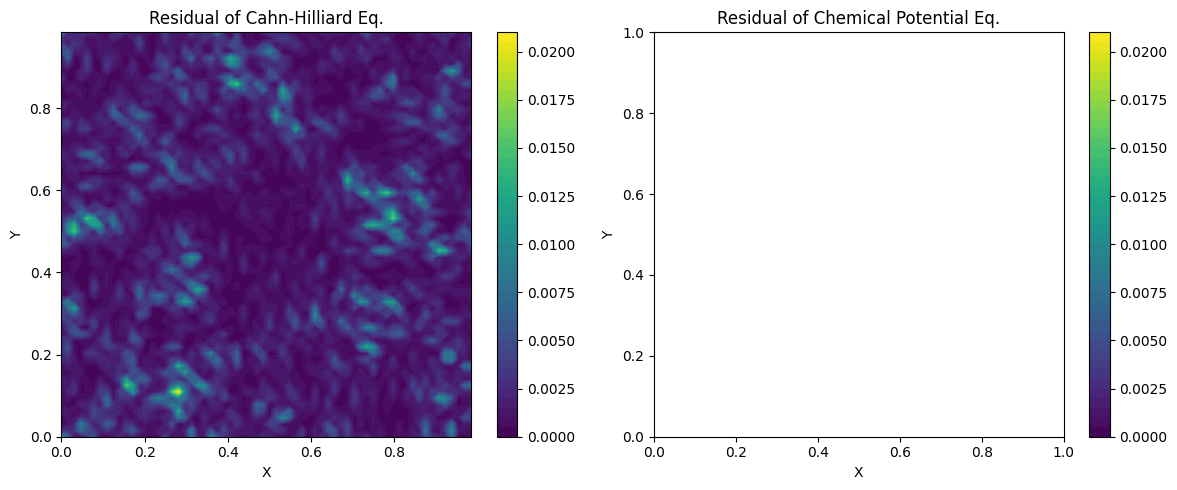

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
im = ax.contourf(meshx, meshy, residual1, levels=50, cmap='viridis')
ax.set_title('Residual of Cahn-Hilliard Eq.')
ax.set_xlabel('X')
ax.set_ylabel('Y')
fig.colorbar(im, ax=ax)

ax = axes[1]
# im = ax.contourf(meshx, meshy, residual2, levels=50, cmap='viridis')
ax.set_title('Residual of Chemical Potential Eq.')
ax.set_xlabel('X')
ax.set_ylabel('Y')
fig.colorbar(im, ax=ax)
fig.tight_layout()

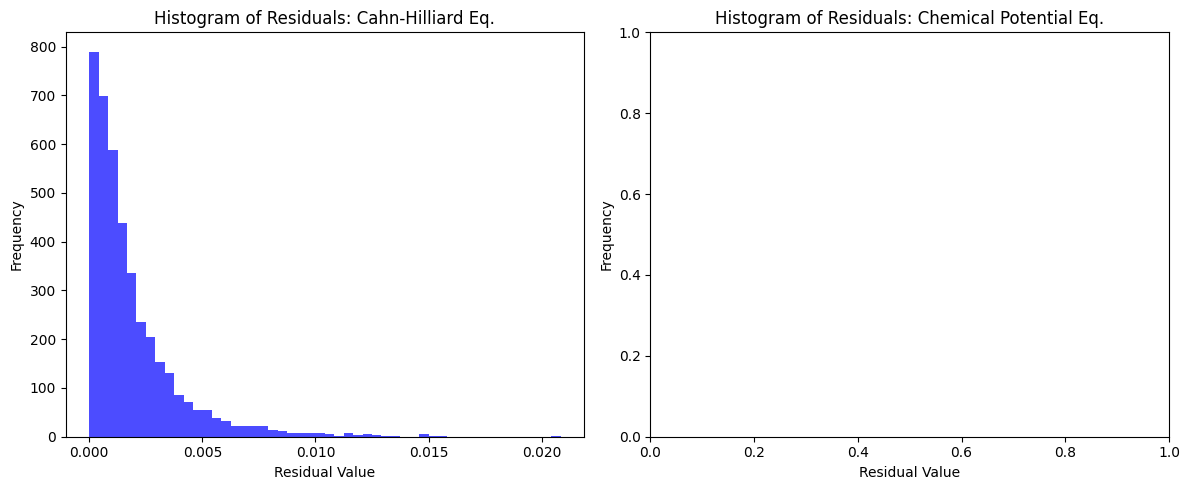

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ax = axes[0]
ax.hist(residual1.flatten(), bins=50, color='blue', alpha=0.7)
ax.set_title('Histogram of Residuals: Cahn-Hilliard Eq.')
ax.set_xlabel('Residual Value')
ax.set_ylabel('Frequency')

ax = axes[1]
# ax.hist(residual2.flatten(), bins=50, color='green', alpha=0.7)
ax.set_title('Histogram of Residuals: Chemical Potential Eq.')
ax.set_xlabel('Residual Value')
ax.set_ylabel('Frequency')
fig.tight_layout()

Mass Min: -3.608875e-09
Mass Max: 4.540198e-09
Mass Fluctuation (Max-Min): 8.149073e-09


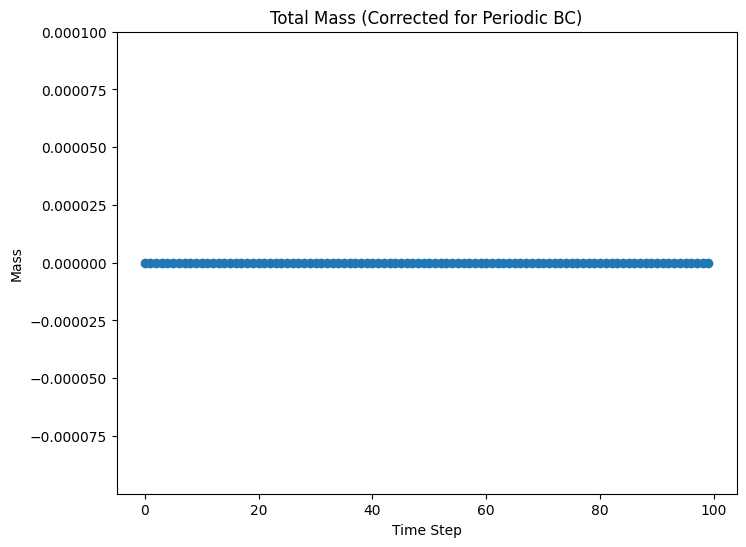

In [22]:
# 修正后的质量守恒验证

# 1. 获取数据 (假设 Xs 是 [Time, Channel, H, W])
# 注意：这里切片取 [:-1, :-1] 以去除重复的右边界和上边界
cs_inner = Xs[0:100, 0,] 

# 2. 计算质量
# 此时形状应该是 (100, 64, 64) 而不是 (100, 65, 65)
mass = jnp.sum(cs_inner, axis=(-1, -2)) * dx * dy * configs.Lc**2

# 3. 打印统计信息
print(f"Mass Min: {mass.min():.6e}")
print(f"Mass Max: {mass.max():.6e}")
print(f"Mass Fluctuation (Max-Min): {mass.max() - mass.min():.6e}")

# 4. 绘图
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(mass, marker='o')
# 限制 y 轴范围以便看清是否是机器误差级别的波动
mean_mass = mass.mean()
ax.set_ylim(mean_mass - 1e-4, mean_mass + 1e-4) 
ax.set_title('Total Mass (Corrected for Periodic BC)')
ax.set_xlabel('Time Step')
ax.set_ylabel('Mass')
plt.show()